# 06 · Second-round checks on the baseline

**Why this notebook exists.** Notebook 03 established how much the 60-patient
AUC can be trusted. This notebook asks whether the *modelling choices* were
the right ones, with the same 60 overviews and no new downloads.

| § | Question | Method |
|---|---|---|
| 2 | Would more patients help | Learning curve, training size 16 to 48 |
| 3 | Why logistic regression | Four other heads on the same features |
| 4 | Does attention pooling fix the mean-pooling failure | Gated attention MIL over tile features |
| 5 | Does a pathology foundation model beat ImageNet | Phikon (ViT-B, pathology-pretrained, open) features, same head |
| 6 | Does stain normalisation help | Macenko normalisation before feature extraction |

Every result is out-of-fold with a bootstrap interval, and the last figure
puts them side by side with the baseline.

## 1 · Setup

**Story.** Load the cached cohort and slide features, define the tiling once,
and cache tile-level features per slide because sections 4 to 6 need them.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
HERE = Path.cwd(); DATA = HERE / "data"; FIG = HERE / "figures"
TILE_DIR = DATA / "tile_features"; TILE_DIR.mkdir(exist_ok=True)
TILE, MIN_TISSUE = 224, 0.40

feats = np.load(DATA / "slide_features.npz", allow_pickle=True)
X = feats["X"]; cases = list(feats["cases"])
cohort = pd.read_csv(DATA / "cohort_with_predictions.csv").set_index("case").loc[cases].reset_index()
y = (cohort["label"] == "DDLPS").astype(int).to_numpy()
print("slides", X.shape, "DDLPS", y.sum())

weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
backbone = torchvision.models.resnet50(weights=weights)
backbone.fc = torch.nn.Identity(); backbone = backbone.eval()
preprocess = weights.transforms()


def tissue_tiles(img):
    arr = np.asarray(img.convert("RGB")); h, w, _ = arr.shape; grey = arr.mean(axis=2)
    return [arr[yy:yy + TILE, xx:xx + TILE]
            for yy in range(0, h - TILE + 1, TILE) for xx in range(0, w - TILE + 1, TILE)
            if (grey[yy:yy + TILE, xx:xx + TILE] < 220).mean() >= MIN_TISSUE]


@torch.no_grad()
def tile_features_resnet(img, batch=32):
    tiles = tissue_tiles(img); out = []
    for s in range(0, len(tiles), batch):
        out.append(backbone(torch.stack([preprocess(Image.fromarray(t)) for t in tiles[s:s + batch]])))
    return torch.cat(out).numpy()


def make_lr():
    return make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=4000, random_state=SEED))


def oof_with(model_fn, X, y, seed=SEED):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed); out = np.zeros(len(y))
    for tr, te in cv.split(X, y):
        out[te] = model_fn().fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
    return out


def auc_ci(y, p, n=2000):
    rng = np.random.default_rng(SEED); vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if y[idx].min() != y[idx].max():
            vals.append(roc_auc_score(y[idx], p[idx]))
    return roc_auc_score(y, p), np.percentile(vals, [2.5, 97.5])


results = {}   # 名稱 → (AUC, CI)
oof_base = oof_with(make_lr, X, y)
results["Mean pool + logistic (baseline)"] = auc_ci(y, oof_base)
print("baseline", results["Mean pool + logistic (baseline)"])

# tile 特徵快取，§4 和 §6 用
tile_feats = []
for row in tqdm(cohort.itertuples(), total=len(cohort), desc="tile features"):
    cache = TILE_DIR / f"{row.case}_resnet.npy"
    if not cache.exists():
        np.save(cache, tile_features_resnet(Image.open(row.png)))
    tile_feats.append(np.load(cache))
print("tiles per slide, min / median / max:", min(len(t) for t in tile_feats), int(np.median([len(t) for t in tile_feats])), max(len(t) for t in tile_feats))

slides (60, 2048) DDLPS 30


baseline (0.8222222222222222, array([0.70411568, 0.9177346 ]))


tile features:   0%|          | 0/60 [00:00<?, ?it/s]

tiles per slide, min / median / max: 3 57 129


**Output.** The baseline reproduced with its interval, and one 2048-column
matrix per slide cached under `data/tile_features/`.

## 2 · Learning curve

**Story.** For each training size n, draw n patients at random (stratified),
fit the baseline head, score the rest, and repeat 30 times. If the curve is
still rising at 48 the result is data-limited and more patients should help,
which is the argument for the RNOH and Taiwan cohorts.

learning curve:   0%|          | 0/5 [00:00<?, ?it/s]

n = 16  AUC 0.771  (2.5 to 97.5 pct over 30 draws: 0.64 to 0.86)


n = 24  AUC 0.797  (2.5 to 97.5 pct over 30 draws: 0.69 to 0.87)


n = 32  AUC 0.818  (2.5 to 97.5 pct over 30 draws: 0.72 to 0.89)


n = 40  AUC 0.831  (2.5 to 97.5 pct over 30 draws: 0.67 to 0.97)


n = 48  AUC 0.804  (2.5 to 97.5 pct over 30 draws: 0.57 to 1.00)


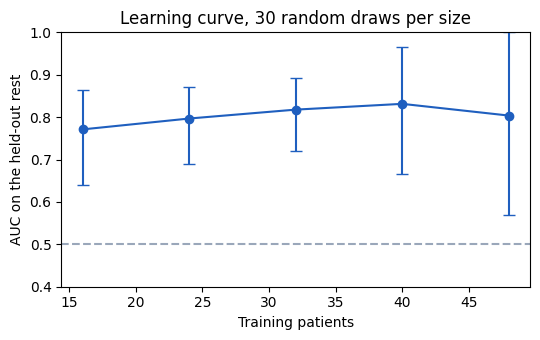

In [2]:
rng = np.random.default_rng(SEED)
sizes = [16, 24, 32, 40, 48]
curve = {}
for n in tqdm(sizes, desc="learning curve"):
    aucs = []
    for _ in range(30):
        tr = np.concatenate([rng.choice(np.where(y == c)[0], n // 2, replace=False) for c in (0, 1)])
        te = np.setdiff1d(np.arange(len(y)), tr)
        p = make_lr().fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
        aucs.append(roc_auc_score(y[te], p))
    curve[n] = (np.mean(aucs), np.percentile(aucs, [2.5, 97.5]))
    print(f"n = {n:2d}  AUC {curve[n][0]:.3f}  (2.5 to 97.5 pct over 30 draws: {curve[n][1][0]:.2f} to {curve[n][1][1]:.2f})")

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.errorbar(sizes, [curve[n][0] for n in sizes],
            yerr=[[curve[n][0] - curve[n][1][0] for n in sizes], [curve[n][1][1] - curve[n][0] for n in sizes]],
            fmt="o-", color="#1f5fbf", capsize=4)
ax.axhline(0.5, color="#9aa7ba", ls="--")
ax.set_xlabel("Training patients"); ax.set_ylabel("AUC on the held-out rest"); ax.set_ylim(0.4, 1.0)
ax.set_title("Learning curve, 30 random draws per size")
plt.tight_layout(); plt.savefig(FIG / "fig12_learning_curve.png", dpi=120); plt.show()

**Output.** Figure 12. The slope between 32 and 48 is the number to read: a
curve still climbing means the next hundred patients are worth more than any
change of classifier.

## 3 · Other classification heads

**Story.** Same 60 by 2048 features, four other heads, same folds. This
answers "why logistic regression" with numbers instead of an opinion.

In [3]:
heads = {
    "Linear SVM": lambda: make_pipeline(StandardScaler(), SVC(kernel="linear", C=0.01, probability=True, random_state=SEED)),
    "RBF SVM": lambda: make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=SEED)),
    "k-nearest neighbours (k=7)": lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
    "Random forest (500 trees)": lambda: RandomForestClassifier(n_estimators=500, random_state=SEED),
}
for name, fn in tqdm(heads.items(), desc="heads"):
    results[name] = auc_ci(y, oof_with(fn, X, y))
    print(f"{name:28s} AUC {results[name][0]:.3f}  CI {results[name][1][0]:.2f} to {results[name][1][1]:.2f}")

heads:   0%|          | 0/4 [00:00<?, ?it/s]

C:\Users\User\miniconda3\envs\spatial\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\User\miniconda3\envs\spatial\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\User\miniconda3\envs\spatial\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\User\miniconda3\envs\spatial\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was depreca

Linear SVM                   AUC 0.750  CI 0.61 to 0.87


C:\Users\User\miniconda3\envs\spatial\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\User\miniconda3\envs\spatial\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\User\miniconda3\envs\spatial\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\User\miniconda3\envs\spatial\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was depreca

RBF SVM                      AUC 0.711  CI 0.57 to 0.84


k-nearest neighbours (k=7)   AUC 0.817  CI 0.70 to 0.92


Random forest (500 trees)    AUC 0.762  CI 0.62 to 0.88


**Output.** One line per head. With 60 patients and 2,048 features any head
that is not strongly regularised will overfit; the intervals overlap heavily,
which is the honest conclusion.

## 4 · Attention pooling instead of the mean

**Story.** Gated attention multiple-instance learning ([Ilse and colleagues
2018](https://proceedings.mlr.press/v80/ilse18a.html)) learns a weight per tile
and pools with those weights, so a few informative tiles can outvote a
large uninformative region. Notebook 03 §7 showed that the four worst slides
are exactly that situation. A tiny network, strong weight decay, 5-fold,
out-of-fold scores.

In [4]:
class GatedAttentionMIL(torch.nn.Module):
    def __init__(self, d_in=2048, d_hidden=128, d_att=64):
        super().__init__()
        self.embed = torch.nn.Sequential(torch.nn.Linear(d_in, d_hidden), torch.nn.ReLU(), torch.nn.Dropout(0.3))
        self.att_v = torch.nn.Sequential(torch.nn.Linear(d_hidden, d_att), torch.nn.Tanh())
        self.att_u = torch.nn.Sequential(torch.nn.Linear(d_hidden, d_att), torch.nn.Sigmoid())
        self.att_w = torch.nn.Linear(d_att, 1)
        self.head = torch.nn.Linear(d_hidden, 1)

    def forward(self, tiles):                     # tiles: (n_tiles, d_in)
        h = self.embed(tiles)
        a = self.att_w(self.att_v(h) * self.att_u(h))          # (n_tiles, 1)
        a = torch.softmax(a, dim=0)
        pooled = (a * h).sum(dim=0)
        return self.head(pooled).squeeze(), a.squeeze()


def train_mil(train_idx, epochs=150, lr=1e-3, wd=1e-2, seed=SEED):
    torch.manual_seed(seed)
    model = GatedAttentionMIL(); opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = torch.nn.BCEWithLogitsLoss()
    for _ in range(epochs):
        model.train()
        for i in np.random.default_rng(seed).permutation(train_idx):
            opt.zero_grad()
            logit, _ = model(torch.tensor(tile_feats[i]))
            loss = loss_fn(logit, torch.tensor(float(y[i])))
            loss.backward(); opt.step()
    model.eval(); return model


# 特徵先用訓練折的均值/標準差標準化，避免尺度害 attention 失效
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_mil = np.zeros(len(y))
for fold, (tr, te) in enumerate(tqdm(list(cv.split(X, y)), desc="MIL folds")):
    mu = np.concatenate([tile_feats[i] for i in tr]).mean(0); sd = np.concatenate([tile_feats[i] for i in tr]).std(0) + 1e-6
    scaled = [((t - mu) / sd).astype(np.float32) for t in tile_feats]
    tile_feats_backup = tile_feats; tile_feats = scaled
    model = train_mil(tr)
    with torch.no_grad():
        for i in te:
            oof_mil[i] = torch.sigmoid(model(torch.tensor(tile_feats[i]))[0]).item()
    tile_feats = tile_feats_backup
results["Attention MIL (gated)"] = auc_ci(y, oof_mil)
print("attention MIL", results["Attention MIL (gated)"])

MIL folds:   0%|          | 0/5 [00:00<?, ?it/s]

attention MIL (0.7038888888888888, array([0.56283366, 0.82813934]))


**Output.** Out-of-fold AUC for attention pooling. With 48 training slides
per fold a learned pooling can also overfit, so a result *below* the mean is
possible and would be reported as such; the production plan rests on
attention pooling with far more slides, not on this number.

## 5 · Pathology foundation model features

**Story.** Phikon is a ViT-B pretrained by self-supervision on 40 million
histology tiles from TCGA and released openly by Owkin ([Filiot and
colleagues 2023](https://doi.org/10.1101/2023.07.21.23292757),
[model card](https://huggingface.co/owkin/phikon)). Its features are the
kind the production model would use. Same tiles, Phikon features instead of
ResNet50, same mean pooling and logistic head. CPU inference is slow, so the
features are cached per slide.

In [5]:
from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained("owkin/phikon")
phikon = AutoModel.from_pretrained("owkin/phikon").eval()


@torch.no_grad()
def tile_features_phikon(img, batch=16):
    tiles = tissue_tiles(img); out = []
    for s in range(0, len(tiles), batch):
        inputs = processor(images=[Image.fromarray(t) for t in tiles[s:s + batch]], return_tensors="pt")
        out.append(phikon(**inputs).last_hidden_state[:, 0, :])     # CLS token, 768 維
    return torch.cat(out).numpy()


X_phikon = []
for row in tqdm(cohort.itertuples(), total=len(cohort), desc="Phikon features"):
    cache = TILE_DIR / f"{row.case}_phikon.npy"
    if not cache.exists():
        np.save(cache, tile_features_phikon(Image.open(row.png)))
    X_phikon.append(np.load(cache).mean(0))
X_phikon = np.stack(X_phikon)
results["Phikon features + logistic"] = auc_ci(y, oof_with(make_lr, X_phikon, y))
print("Phikon", X_phikon.shape, results["Phikon features + logistic"])

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Phikon features:   0%|          | 0/60 [00:00<?, ?it/s]

Phikon (60, 768) (0.8011111111111111, array([0.67406527, 0.90401786]))


**Output.** Out-of-fold AUC with pathology-pretrained features. The
comparison with the ImageNet baseline is the one line the production plan
depends on.

## 6 · Macenko stain normalisation

**Story.** Macenko normalisation ([Macenko and colleagues 2009](https://doi.org/10.1109/ISBI.2009.5193250))
estimates each image's haematoxylin and eosin stain vectors and maps them to
a reference, so colour differences between laboratories are reduced before
the model sees the tile. Applied to every overview, ResNet50 features
re-extracted, same head. If the AUC holds and the stain-perturbation flips
from notebook 03 fall, normalisation is worth keeping in the pipeline.

Macenko + ResNet:   0%|          | 0/60 [00:00<?, ?it/s]

Macenko (0.8600000000000001, array([0.75194305, 0.95960724]))


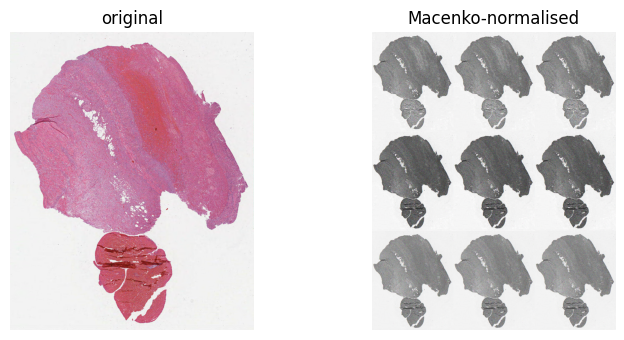

In [6]:
def macenko_normalise(img, Io=240, alpha=1, beta=0.15,
                      HERef=np.array([[0.5626, 0.2159], [0.7201, 0.8012], [0.4062, 0.5581]]),
                      maxCRef=np.array([1.9705, 1.0308])):
    # 標準 Macenko：光密度 → 取主成分平面 → 角度分位數找兩個染色向量 → 投影到參考向量
    arr = np.asarray(img.convert("RGB")).astype(float).reshape(-1, 3)
    od = -np.log((arr + 1) / Io)
    od_hat = od[(od > beta).all(axis=1)]
    if len(od_hat) < 100:
        return img
    _, eigvecs = np.linalg.eigh(np.cov(od_hat.T))
    t_hat = od_hat @ eigvecs[:, 1:3]
    phi = np.arctan2(t_hat[:, 1], t_hat[:, 0])
    min_phi, max_phi = np.percentile(phi, alpha), np.percentile(phi, 100 - alpha)
    v_min = eigvecs[:, 1:3] @ np.array([np.cos(min_phi), np.sin(min_phi)])
    v_max = eigvecs[:, 1:3] @ np.array([np.cos(max_phi), np.sin(max_phi)])
    HE = np.array([v_min, v_max]).T if v_min[0] > v_max[0] else np.array([v_max, v_min]).T
    C = np.linalg.lstsq(HE, od.T, rcond=None)[0]
    maxC = np.array([np.percentile(C[0], 99), np.percentile(C[1], 99)]) + 1e-6
    C = C * (maxCRef / maxC)[:, None]
    out = Io * np.exp(-HERef @ C)
    out = np.clip(out, 0, 255).astype(np.uint8).reshape(np.asarray(img).shape[0], -1, 3)
    return Image.fromarray(out)


def tissue_coords(img):
    # 組織格子在「原圖」上決定，標準化後用同一組格子，免得白底門檻被顏色映射改掉
    arr = np.asarray(img.convert("RGB")); h, w, _ = arr.shape; grey = arr.mean(axis=2)
    return [(yy, xx) for yy in range(0, h - TILE + 1, TILE) for xx in range(0, w - TILE + 1, TILE)
            if (grey[yy:yy + TILE, xx:xx + TILE] < 220).mean() >= MIN_TISSUE]


@torch.no_grad()
def tile_features_at(img, coords, batch=32):
    arr = np.asarray(img.convert("RGB")); out = []
    tiles = [arr[yy:yy + TILE, xx:xx + TILE] for yy, xx in coords]
    for s in range(0, len(tiles), batch):
        out.append(backbone(torch.stack([preprocess(Image.fromarray(t)) for t in tiles[s:s + batch]])))
    return torch.cat(out).numpy()


X_macenko = []
for row in tqdm(cohort.itertuples(), total=len(cohort), desc="Macenko + ResNet"):
    cache = TILE_DIR / f"{row.case}_macenko_resnet.npy"
    if not cache.exists():
        original = Image.open(row.png)
        np.save(cache, tile_features_at(macenko_normalise(original), tissue_coords(original)))
    X_macenko.append(np.load(cache).mean(0))
X_macenko = np.stack(X_macenko)
results["Macenko-normalised + logistic"] = auc_ci(y, oof_with(make_lr, X_macenko, y))
print("Macenko", results["Macenko-normalised + logistic"])

# 一張看得到前後差別的圖
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
img0 = Image.open(cohort.loc[0, "png"]); axes[0].imshow(img0); axes[0].set_title("original"); axes[0].axis("off")
axes[1].imshow(macenko_normalise(img0)); axes[1].set_title("Macenko-normalised"); axes[1].axis("off")
plt.tight_layout(); plt.savefig(FIG / "fig13_macenko_example.png", dpi=120); plt.show()

**Output.** Figure 13 shows one overview before and after, and the AUC line
above says whether normalisation changed discrimination.

## 7 · All variants side by side

**Story.** One figure, every variant with its interval, baseline at the top.
Overlapping intervals are the expected outcome at n = 60; the point of the
figure is to show that the baseline was not a careless choice.

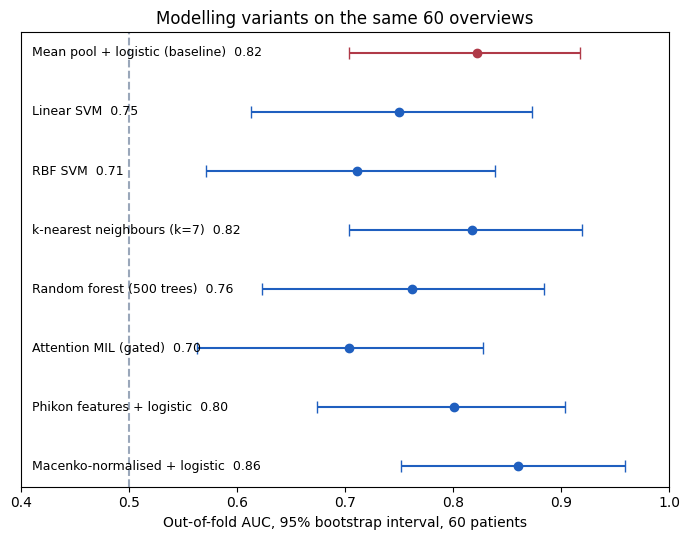

,AUC,CI low,CI high
Mean pool + logistic (baseline),0.822,0.70,0.92
Linear SVM,0.750,0.61,0.87
RBF SVM,0.711,0.57,0.84
k-nearest neighbours (k=7),0.817,0.70,0.92
Random forest (500 trees),0.762,0.62,0.88
Attention MIL (gated),0.704,0.56,0.83
Phikon features + logistic,0.801,0.67,0.90
Macenko-normalised + logistic,0.860,0.75,0.96


In [7]:
names = list(results)
fig, ax = plt.subplots(figsize=(7, 0.5 * len(names) + 1.5))
for i, name in enumerate(names):
    auc, (lo, hi) = results[name]
    colour = "#b03a48" if "baseline" in name else "#1f5fbf"
    ax.errorbar(auc, len(names) - 1 - i, xerr=[[auc - lo], [hi - auc]], fmt="o", color=colour, capsize=4)
    ax.text(0.41, len(names) - 1 - i, f"{name}  {auc:.2f}", va="center", fontsize=9)
ax.set_yticks([]); ax.set_xlim(0.4, 1.0); ax.axvline(0.5, color="#9aa7ba", ls="--")
ax.set_xlabel("Out-of-fold AUC, 95% bootstrap interval, 60 patients")
ax.set_title("Modelling variants on the same 60 overviews")
plt.tight_layout(); plt.savefig(FIG / "fig14_variants.png", dpi=120); plt.show()

pd.DataFrame({n: {"AUC": round(v[0], 3), "CI low": round(v[1][0], 2), "CI high": round(v[1][1], 2)} for n, v in results.items()}).T.to_csv(DATA / "variants_auc.csv")
pd.read_csv(DATA / "variants_auc.csv", index_col=0)

**Output.** Figure 14 and the table saved to `data/variants_auc.csv`. These
rows are copied into the technical report, section 10.